# 00 — Daily Calibration
Run every day before experiments. Goal: ~15–30 min.
Updates: readout frequency, single shot threshold + phase, f_ge, f_ef.

In [1]:
print('Daily calibration starting...')

Daily calibration starting...


In [3]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2')
sys.path.insert(0, 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2\\measurement_notebooks')
import numpy as np
import matplotlib.pyplot as plt
from meas_utils import MultimodeStation
from calibration_helpers import (
    init_helpers,
    do_res_spec, update_res_spec,
    do_single_shot, update_single_shot,
    do_t2_ramsey, update_t2_ramsey_ge, update_t2_ramsey_ef,
)

station = MultimodeStation(
    experiment_name  = '2600403_lmm',
    hardware_config  = 'hardware_config_20260111.yml',
)
init_helpers(station)
config_thisrun = station.config_thisrun
cfg_dict       = station.cfg_dict
meas           = station.meas
print('Station ready.')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
connected proxies, ns= <Pyro4.core.Proxy at 0x21f4fcc35c0; connected IPv4; for PYRO:Pyro.NameServer@10.108.30.32:9090>
Path added at highest priority
['C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2', 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2\\measurement_notebooks', 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2', 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2', 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2\\measurement_notebooks', 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2', 'C:\\_Lib\\python', 'C:\\_Lib\\python\\slab', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\python313.zip', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\DLLs', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\Lib', 'c:\\ProgramData\\Anaconda3\\envs\\mm313', '', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\Lib\\site-packages']
Experiments module p

## Resonator Spectroscopy (quick)

In [ ]:
from yoko_current_sweep import * 
dcflux = connect_yoko(address='10.108.30.37')
print(f'Current: {dcflux.get_current()*1e3:.4f} mA')
ramp_current_mA(dcflux, 0.00)    

Connected to Yokogawa at 10.108.30.37
Current output: 0.0000 mA
Current: 0.0000 mA
Ramping 0.0000 → 0.0000 mA  (0.01 mA/s, ETA 0.0s)
Done. Current: 0.0000 mA


In [5]:
config_thisrun.hw.soc.dacs.readout.fc = 7600
config_thisrun.hw.soc.dacs.readout.att = [30,0]
station.handle_config_update(True)

Comparing configurations:
Configuration updated and saved, excluding storage_man_file.


In [6]:
config_thisrun.device.readout

{'trig_offset': 0.5,
 'frequency': 7600.419829610536,
 'gain': 0.2,
 'phase': 46.71898553353748,
 'length': 3,
 'threshold': -7.845181049976851,
 'threshold_list': [0],
 'final_delay': 250,
 'confusion_matrix_with_reset': [0.9964530022802125,
  0.0035469977197875036,
  0.013768302080657598,
  0.9862316979193424],
 'confusion_matrix_without_reset': [0.9383999999999999,
  0.0616000000000001,
  0.0458,
  0.9542],
 'Ie': -6.432409414715889,
 'Ig': -118.96377789073908,
 'confusion_matrix_with_active_reset': [0.9624598666337363,
  0.03754013336626372,
  0.04206175540967661,
  0.9579382445903234]}

In [7]:
rspec = do_res_spec(
    config_thisrun                = config_thisrun,
    frequency                     = config_thisrun.device.readout.frequency,
    span                          = 10,
    expts                         = 150,
    reps                          = 200,
    rounds                        = 1,
    gain                          = 0.2, #config_thisrun.device.readout.gain,
    length                        = config_thisrun.device.readout.length,
    final_delay                   = 250,
    pulse_e                       = False,
    prepulse                      = {},
    analyze_and_display           = False,
    use_config_params_for_readout = False,
)

connected proxies, ns= <Pyro4.core.Proxy at 0x21f727e2580; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
entering initialize sweep vars 
param name:  frequency
param values:  {'label': 'readout_pulse', 'param': 'freq', 'param_type': 'pulse', 'start': 7595.419829610536, 'step': 0.06666666666666667, 'expts': 150}
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': <qick.asm_v2.QickParam object at 0x0000021F727AF380>, 'phase': 46.71898553353748, 'gain': 0.2, 'length': 3}
922
307.2
pulsing resonator
triggering readout at time 0.5
10
430.08


  0%|          | 0/30000 [00:00<?, ?it/s]

Saving S:\Multimode\experiment\2600403_lmm\data\00349_ResonatorSpectroscopyExperiment.h5


new display function for spectroscopy
Data 1 - Found peak in amps at 7600.364 MHz, HWHM 0.735
Data 1 - Found peak in avgi at 7602.100 MHz, HWHM -0.001
Data 1 - Found peak in avgq at 7600.386 MHz, HWHM 0.986


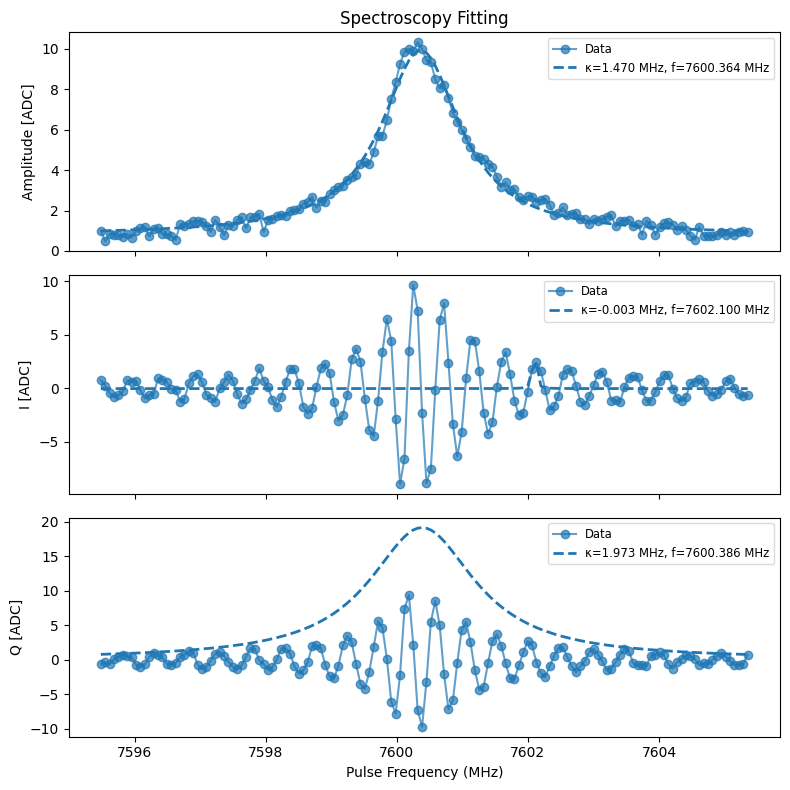

fname  S:\Multimode\experiment\2600403_lmm\plots\2026-04-14_15-11-45_Spectroscopy_Fitting.png
Plot saved to S:\Multimode\experiment\2600403_lmm\plots\2026-04-14_15-11-45_Spectroscopy_Fitting.png
Plot reference appended to S:\Multimode\experiment\2600403_lmm\logs\2026-04-14.md


In [8]:
spec_analysis = meas.SpectroscopyFitting(#title='Readout Spectroscopy',
                                         data=rspec.data, station=station)
spec_analysis.analyze()
spec_analysis.display()

In [70]:
config_thisrun.device.readout.gain = 0.2 
station.handle_config_update(True)

Comparing configurations:
Key 'device.readout.gain' differs:
  Old value (config1): 0.30000000000000004
  New value (config2): 0.2
Configuration updated and saved, excluding storage_man_file.


In [ ]:
update_res_spec(
    rspec          = spec_analysis,
    config_thisrun = config_thisrun,
)
# station.handle_config_update(True)

Updated readout frequency to 7600.420 MHz
Comparing configurations:
Key 'device.readout.frequency' differs:
  Old value (config1): 7600.397
  New value (config2): 7600.419829610536
Configuration updated and saved, excluding storage_man_file.


## Single Shot

connected proxies, ns= <Pyro4.core.Proxy at 0x25c0be71c10; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
Using readout: gain=0.2, length=3.0, frequency=7600.419829610536
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': 7600.419829610536, 'phase': 46.71898553353748, 'gain': 0.2, 'length': 3.0}
922
307.2
pulsing resonator
triggering readout at time 0.5
10
430.08


  0%|          | 0/5000 [00:00<?, ?it/s]

pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': 7600.419829610536, 'phase': 46.71898553353748, 'gain': 0.2, 'length': 3.0}
922
307.2
pulsing e
pulsing resonator
triggering readout at time 0.5
10
430.08


  0%|          | 0/5000 [00:00<?, ?it/s]

Fidelity: 27.25%
Rotation Angle: -8.59 degrees
Threshold: -6.49
fname  S:\Multimode\experiment\2600403_lmm\plots\2026-04-14_11-52-20_histogram.png
Plot saved to S:\Multimode\experiment\2600403_lmm\plots\2026-04-14_11-52-20_histogram.png
Plot reference appended to S:\Multimode\experiment\2600403_lmm\logs\2026-04-14.md


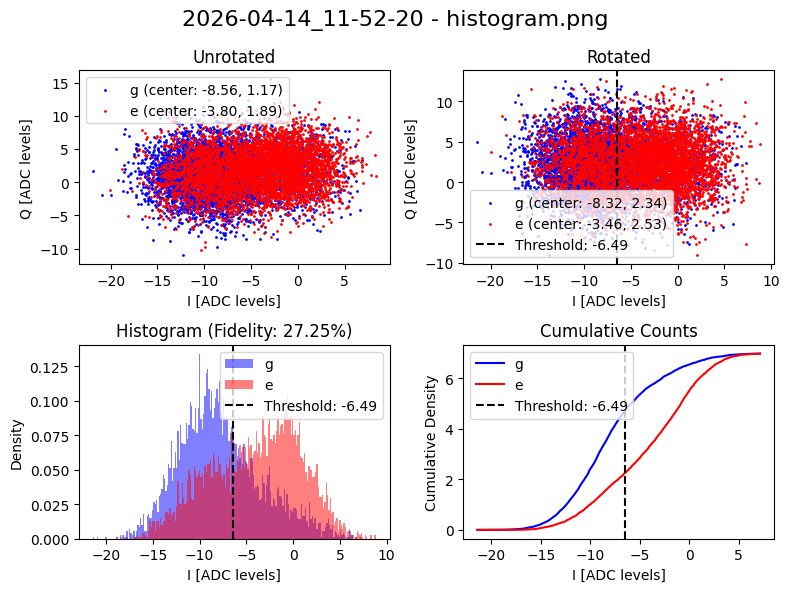

In [81]:
hst = do_single_shot(
    config_thisrun       = config_thisrun,
    readout_gain         = 1.0*config_thisrun.device.readout.gain,
    readout_length       = 1.0*config_thisrun.device.readout.length,
    readout_frequency    = config_thisrun.device.readout.frequency,
    shots                = 5000,
    pulse_e              = True,
    prepulse             = {},
    sweep_params         = {},
    final_delay          = 250,
    analyze_and_display  = True,
)

In [ ]:
# config_thisrun.device.readout.gain = 1.5*config_thisrun.device.readout.gain

In [ ]:
# station.handle_config_update(True)

Comparing configurations:
Key 'device.readout.gain' differs:
  Old value (config1): 0.2
  New value (config2): 0.30000000000000004
Key 'device.readout.phase' differs:
  Old value (config1): -70.4279874205774
  New value (config2): 46.71898553353748
Key 'device.readout.threshold' differs:
  Old value (config1): -0.9124381965829471
  New value (config2): -7.845181049976851
Configuration updated and saved, excluding storage_man_file.


In [63]:
update_single_shot(
    hst_analysis   = hst,
    config_thisrun = config_thisrun,
)

Updated readout: fidelity=0.386, threshold=-7.845, angle=117.147 deg


## Amplitude Rabi ge 

In [3]:
from calibration_helpers import do_rabi, update_amplitude_rabi_ge

In [53]:
config_thisrun.hw.soc.dacs.qubit

{'ch': 0,
 'type': 'full',
 'nyquist': 1,
 'ftype': 'bandpass',
 'bw': 2,
 'fc': 3600,
 'att': [10, 0]}

In [58]:
config_thisrun.hw.soc.dacs.qubit.att= [1,0]
station.handle_config_update(True)

Comparing configurations:
Key 'hw.soc.dacs.qubit.att' differs:
  Old value (config1): [10, 0]
  New value (config2): [1, 0]
Configuration updated and saved, excluding storage_man_file.


In [61]:
rabi_ge = do_rabi(
    config_thisrun      = config_thisrun,
    cfg_dict            = cfg_dict,
    start               = 0.001,
    expts               = 300,
    reps                = 500,
    rounds              = 1,
    pulse_type          = 'gauss',
    sweep               = 'amp',
    chan                = config_thisrun.hw.soc.dacs.qubit.ch,
    freq                = config_thisrun.device.qubit.f_ge,
    gain                = 0.0,
    sigma               = 0.05,
    sigma_inc           = 4,
    length              = 0.0,
    ramp_sigma          = 0.02,
    ramp_sigma_inc      = 0.0,
    n_pulses            = 1,
    prepulse            = {},
    postpulse           = {},
    max_gain            = 1.0,
    max_length          = 10.0,
    sweep_other_param   = {},
)


connected proxies, ns= <Pyro4.core.Proxy at 0x25c133d7dd0; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
{'start': 0.001, 'max_gain': 1.0, 'max_length': 10.0, 'expts': 300, 'reps': 500, 'rounds': 1, 'sigma_test': None, 'sweep': 'amp', 'chan': 0, 'freq': 3704.7966, 'type': 'gauss', 'gain': 0.0, 'sigma': 0.05, 'step': 0.00333, 'sigma_inc': 4, 'length': 0.0, 'ramp_sigma': 0.02, 'ramp_sigma_inc': 0.0, 'prepulse': {}, 'postpulse': {}, 'n_pulses': 1, 'final_delay': 250, 'sweep_other_param': {}}
{'gain': {'label': 'rabi_pulse', 'param': 'gain', 'param_type': 'pulse', 'start': 0.001, 'step': 0.00333, 'expts': 300}}
entering initialize sweep vars 
param name:  gain
param values:  {'label': 'rabi_pulse', 'param': 'gain', 'param_type': 'pulse', 'start': 0.001, 'step': 0.00333, 'expts': 300}
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': 7600.419829610536, 'phase': 46.71898553353748, 'gain': 0.30000000000000004, 'length': 3}
92

  0%|          | 0/150000 [00:00<?, ?it/s]

Attempted to init fitparam 4 to -6.215531105129898, which is out of bounds 3.0677765726681128 to 4.099021691973969. Instead init to 3.5833991323210412
Attempted to init fitparam 4 to 3.5833991323210412, which is out of bounds 5.148230935359063 to 9.375143487044136. Instead init to 7.2616872112015995


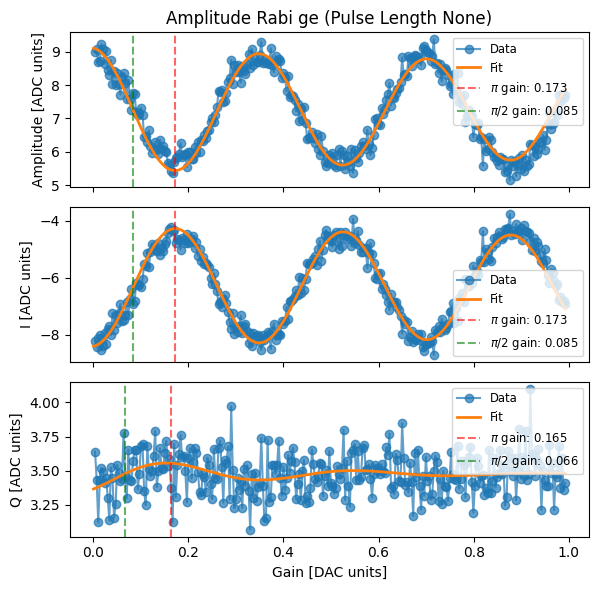

In [62]:
rabi_ge.analyze(fitparams = [None, None, None, None, None, None]) # [yscale, freq, phase_deg, decay, y0, x0]
rabi_ge.display(title_str='Amplitude Rabi ge')


In [63]:
update_amplitude_rabi_ge(
    amprabi        = rabi_ge, 
    config_thisrun = config_thisrun,
)

Comparing configurations:
Key 'device.qubit.pulses.pi_ge.gain' differs:
  Old value (config1): 0.095
  New value (config2): 0.173
Key 'device.qubit.pulses.pi_ge.sigma' differs:
  Old value (config1): 0.03
  New value (config2): 0.05
Key 'device.qubit.pulses.hpi_ge.gain' differs:
  Old value (config1): 0.048
  New value (config2): 0.085
Key 'device.qubit.pulses.hpi_ge.sigma' differs:
  Old value (config1): 0.03
  New value (config2): 0.05
Configuration updated and saved, excluding storage_man_file.
Updated ge pi/hpi gain and sigma.


In [33]:
config_thisrun.hw.soc.dacs.qubit

{'ch': 0,
 'type': 'full',
 'nyquist': 1,
 'ftype': 'bandpass',
 'bw': 1.0,
 'fc': 3600,
 'att': [10, 0]}

In [7]:
# length 
rabi_ge = do_rabi(
    config_thisrun      = config_thisrun,
    cfg_dict            = cfg_dict,
    start               = 0.01,
    expts               = 30,
    reps                = 500,
    rounds              = 1,
    pulse_type          = 'flat_top',
    sweep               = 'length',
    chan                = config_thisrun.hw.soc.dacs.qubit.ch,
    freq                = config_thisrun.device.qubit.f_ge,
    gain                = 0.1,
    sigma               = 0.05,
    sigma_inc           = 4,
    length              = 0.0,
    ramp_sigma          = 0.02,
    ramp_sigma_inc      = 4,
    n_pulses            = 1,
    prepulse            = {},
    postpulse           = {},
    max_gain            = 1.0,
    max_length          =0.8,
    sweep_other_param   = {},
)


connected proxies, ns= <Pyro4.core.Proxy at 0x1b3f67e5390; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
{'start': 0.01, 'max_gain': 1.0, 'max_length': 0.8, 'expts': 30, 'reps': 500, 'rounds': 1, 'sigma_test': None, 'sweep': 'length', 'chan': 0, 'freq': 3704.8173, 'type': 'flat_top', 'gain': 0.1, 'sigma': 0.05, 'step': 0.026333333333333334, 'sigma_inc': 4, 'length': 0.0, 'ramp_sigma': 0.02, 'ramp_sigma_inc': 4, 'prepulse': {}, 'postpulse': {}, 'n_pulses': 1, 'final_delay': 250, 'sweep_other_param': {}}
Configuring length sweep
{'length': {'label': 'rabi_pulse', 'param': 'length', 'param_type': 'pulse', 'start': 0.01, 'step': 0.026333333333333334, 'expts': 30}}
entering initialize sweep vars 
param name:  length
param values:  {'label': 'rabi_pulse', 'param': 'length', 'param_type': 'pulse', 'start': 0.01, 'step': 0.026333333333333334, 'expts': 30}
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': 7600.419829610536, 'ph

  0%|          | 0/15000 [00:00<?, ?it/s]

Attempted to init fitparam 4 to -6.086003141596231, which is out of bounds 1.1153904555314536 to 2.1165813449023863. Instead init to 1.61598590021692
Attempted to init fitparam 4 to 1.61598590021692, which is out of bounds 4.529018391106619 to 8.348008506173292. Instead init to 6.438513448639956


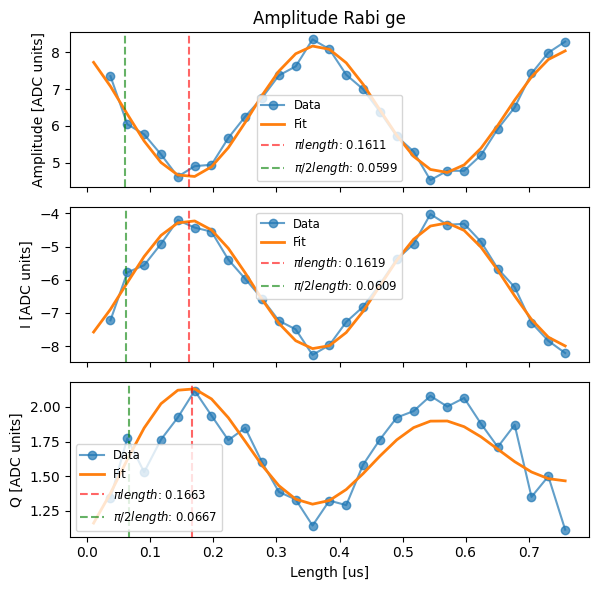

In [8]:
rabi_ge.analyze(fitparams = [None, None, None, None, None, None]) # [yscale, freq, phase_deg, decay, y0, x0]
rabi_ge.display(title_str='Amplitude Rabi ge')

## T2 Ramsey GE — Frequency Correction

connected proxies, ns= <Pyro4.core.Proxy at 0x25c135efad0; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
{'wait_time': {'label': 'wait', 'param': 't', 'param_type': 'time', 'start': 0.01, 'step': 0.02, 'expts': 300}}
entering initialize sweep vars 
param name:  wait_time
param values:  {'label': 'wait', 'param': 't', 'param_type': 'time', 'start': 0.01, 'step': 0.02, 'expts': 300}
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': 7600.419829610536, 'phase': 46.71898553353748, 'gain': 0.2, 'length': 3}
922
307.2
{'sigma': 0.05, 'sigma_inc': 4, 'freq': 3704.7966, 'gain': 0.085, 'phase': 0, 'type': 'gauss'}
pulsing resonator
triggering readout at time 0.5
10
430.08


  0%|          | 0/90000 [00:00<?, ?it/s]

Echoes in the data
No echoes in the data
Attempted to init fitparam 4 to -6.0912285128946735, which is out of bounds 0.9405712219812004 to 2.300610990600145. Instead init to 1.6205911062906726
[I]  f_fit=0.5793 MHz  |  candidates: 3704.8173, 3705.9759 MHz  |  correction=+0.0207, +1.1793  MHz
[Q]  f_fit=0.5811 MHz  |  candidates: 3704.8155, 3705.9777 MHz  |  correction=+0.0189, +1.1811  MHz


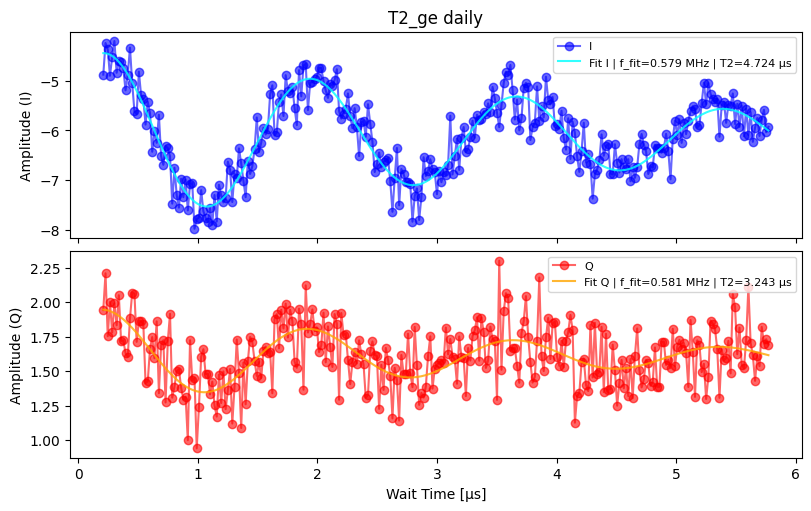

In [71]:
t2_ge = do_t2_ramsey(
    config_thisrun      = config_thisrun,
    cfg_dict            = cfg_dict,
    prepulse            = {},
    postpulse           = {},
    start               = 0.01,
    step_size           = 0.02,
    expts               = 300,
    ramsey_freq         = 0.6,
    reps                = 300,
    rounds              = 1,
    sigma               = config_thisrun.device.qubit.pulses.hpi_ge.sigma,
    sigma_inc           = 4,
    freq                = config_thisrun.device.qubit.f_ge,
    gain                = config_thisrun.device.qubit.pulses.hpi_ge.gain,
    pulse_type          = 'gauss',
    analyze_and_display = False,
    sweep_other_param   = {},
)
t2_ge_fit = meas.RamseyFitting(t2_ge.data, config=t2_ge.cfg)
t2_ge_fit.analyze(fitparams=[None, 0.5, None, None, None, None])
t2_ge_fit.display(title_str='T2_ge daily')

In [72]:
# update_t2_ramsey_ge(
#     t2ramsey       = t2_ge_fit,
#     config_thisrun = config_thisrun,
# )
config_thisrun.device.qubit.f_ge = 3704.8173
station.handle_config_update(True)

Comparing configurations:
Key 'device.qubit.f_ge' differs:
  Old value (config1): 3704.7966
  New value (config2): 3704.8173
Configuration updated and saved, excluding storage_man_file.


## Amplitude rabi ef 

In [76]:
from calibration_helpers import update_amplitude_rabi_ef

In [73]:
rabi_ef = do_rabi(
    config_thisrun      = config_thisrun,
    cfg_dict            = cfg_dict,
    start               = 0.001,
    expts               = 300,
    reps                = 500,
    rounds              = 1,
    pulse_type          = 'gauss',
    sweep               = 'amp',
    chan                = config_thisrun.hw.soc.dacs.qubit.ch,
    freq                = config_thisrun.device.qubit.f_ef,
    gain                = 0.0,
    sigma               = 0.05,
    sigma_inc           = 4,
    length              = 0.0,
    ramp_sigma          = 0.02,
    ramp_sigma_inc      = 0.0,
    n_pulses            = 1,
    prepulse            = {'pi_qubit_ge': {}},
    postpulse           = {'pi_qubit_ge': {}},
    max_gain            = 1.0,
    max_length          = 10.0,
    sweep_other_param   = {},
)

connected proxies, ns= <Pyro4.core.Proxy at 0x25c0baca090; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
{'start': 0.001, 'max_gain': 1.0, 'max_length': 10.0, 'expts': 300, 'reps': 500, 'rounds': 1, 'sigma_test': None, 'sweep': 'amp', 'chan': 0, 'freq': 3593.7238, 'type': 'gauss', 'gain': 0.0, 'sigma': 0.05, 'step': 0.00333, 'sigma_inc': 4, 'length': 0.0, 'ramp_sigma': 0.02, 'ramp_sigma_inc': 0.0, 'prepulse': {'pi_qubit_ge': {}}, 'postpulse': {'pi_qubit_ge': {}}, 'n_pulses': 1, 'final_delay': 250, 'sweep_other_param': {}}
{'gain': {'label': 'rabi_pulse', 'param': 'gain', 'param_type': 'pulse', 'start': 0.001, 'step': 0.00333, 'expts': 300}}
entering initialize sweep vars 
param name:  gain
param values:  {'label': 'rabi_pulse', 'param': 'gain', 'param_type': 'pulse', 'start': 0.001, 'step': 0.00333, 'expts': 300}
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': 7600.419829610536, 'phase': 46.71898553353748, 'gain': 0.

  0%|          | 0/150000 [00:00<?, ?it/s]

Attempted to init fitparam 1 to 138.74100211714892, which is out of bounds 0.1008743303983745 to 50.43716519918724. Instead init to 25.26901976479281


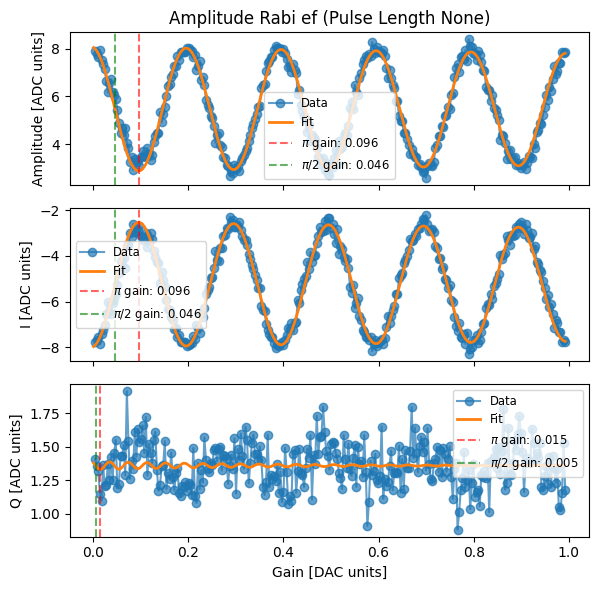

In [74]:
rabi_ef.analyze()
rabi_ef.display(title_str='Amplitude Rabi ef')

In [77]:
update_amplitude_rabi_ef(
    amprabi        = rabi_ef, 
    config_thisrun = config_thisrun,
)

Comparing configurations:
Key 'device.qubit.pulses.pi_ef.gain' differs:
  Old value (config1): 0.042
  New value (config2): 0.096
Key 'device.qubit.pulses.pi_ef.sigma' differs:
  Old value (config1): 0.03
  New value (config2): 0.05
Key 'device.qubit.pulses.hpi_ef.gain' differs:
  Old value (config1): 0.02
  New value (config2): 0.046
Key 'device.qubit.pulses.hpi_ef.sigma' differs:
  Old value (config1): 0.03
  New value (config2): 0.05
Configuration updated and saved, excluding storage_man_file.
Updated ef pi/hpi gain and sigma.


In [78]:
station.handle_config_update(True)

Comparing configurations:
Configuration updated and saved, excluding storage_man_file.


## T2 Ramsey EF — Frequency Correction

connected proxies, ns= <Pyro4.core.Proxy at 0x25c10263890; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
{'wait_time': {'label': 'wait', 'param': 't', 'param_type': 'time', 'start': 0.01, 'step': 0.02, 'expts': 300}}
entering initialize sweep vars 
param name:  wait_time
param values:  {'label': 'wait', 'param': 't', 'param_type': 'time', 'start': 0.01, 'step': 0.02, 'expts': 300}
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': 7600.419829610536, 'phase': 46.71898553353748, 'gain': 0.2, 'length': 3}
922
307.2
{'sigma': 0.05, 'sigma_inc': 4, 'freq': 3593.7238, 'gain': 0.046, 'phase': 0, 'type': 'gauss'}
Applied prepulse:  pi_qubit_ge
Applied postpulse:  pi_qubit_ge
pulsing resonator
triggering readout at time 0.5
10
430.08


  0%|          | 0/90000 [00:00<?, ?it/s]

Echoes in the data
No echoes in the data
Attempted to init fitparam 4 to -5.197305688117619, which is out of bounds 0.7571185827910341 to 2.0050325379609544. Instead init to 1.381075560375994
[I]  f_fit=0.6498 MHz  |  candidates: 3593.6740, 3594.9736 MHz  |  correction=-0.0498, +1.2498  MHz
[Q]  f_fit=0.6458 MHz  |  candidates: 3593.6780, 3594.9696 MHz  |  correction=-0.0458, +1.2458  MHz


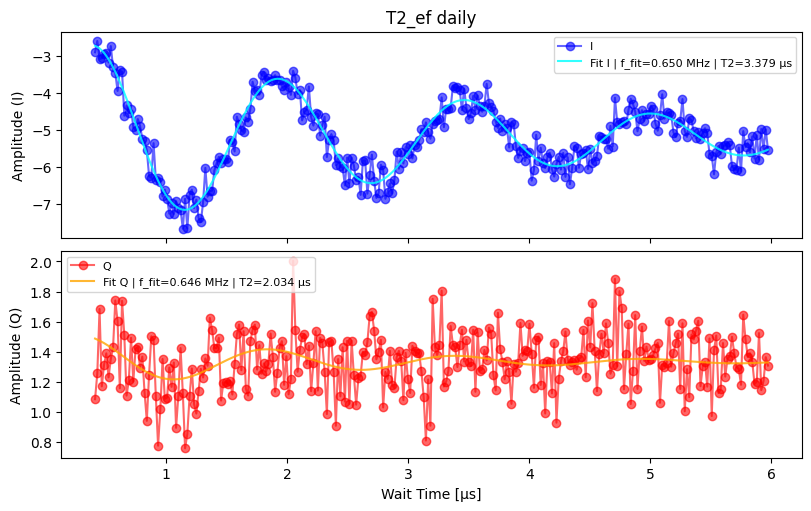

In [79]:
t2_ef = do_t2_ramsey(
    config_thisrun      = config_thisrun,
    cfg_dict            = cfg_dict,
    prepulse            = {'pi_qubit_ge': {}},
    postpulse           = {'pi_qubit_ge': {}},
    start               = 0.01,
    step_size           = 0.02,
    expts               = 300,
    ramsey_freq         = 0.6,
    reps                = 300,
    rounds              = 1,
    sigma               = config_thisrun.device.qubit.pulses.hpi_ef.sigma,
    sigma_inc           = 4,
    freq                = config_thisrun.device.qubit.f_ef,
    gain                = config_thisrun.device.qubit.pulses.hpi_ef.gain,
    pulse_type          = 'gauss',
    analyze_and_display = False,
    sweep_other_param   = {},
)
t2_ef_fit = meas.RamseyFitting(t2_ef.data, config=t2_ef.cfg)
t2_ef_fit.analyze(fitparams=[None, 0.5, None, None, None, None])
t2_ef_fit.display(title_str='T2_ef daily')

In [80]:
config_thisrun.device.qubit.f_ef = 3593.6740
station.handle_config_update(True)

Comparing configurations:
Key 'device.qubit.f_ef' differs:
  Old value (config1): 3593.7238
  New value (config2): 3593.674
Configuration updated and saved, excluding storage_man_file.


In [ ]:
update_t2_ramsey_ef(
    t2ramsey       = t2_ef_fit,
    config_thisrun = config_thisrun,
)

## Save Config

In [ ]:
station.handle_config_update(write_to_file=True)
print('Config saved.')